# Лабораторная работа №5

# Моделирование статистических зависимостей

**Цель работы:**
Структурная и параметрическая идентификация модели зависимости частоты преступлений от возраста в Москве в 2021 году.
Провела анализ с использованием Python, рассчитала параметры моделей, коэффициент детерминации и визуализировала результаты.

In [1]:
# Импорт библиотек
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import sqrt

In [2]:
# Загрузка данных
with open("Москва_2021.txt", "r", encoding="utf-8") as file:
    data = [int(line.strip()) for line in file if line.strip()]

## Предварительный анализ данных

In [4]:
# Дискретный ряд распределения
age_freq = {}
for age in data:
    age_freq[age] = age_freq.get(age, 0) + 1

x_data = sorted(age_freq.keys())  # x - возраст
y_data = [age_freq[age] for age in x_data]  # y - частота преступлений

print("Ряд распределения:")
print("x (возраст):", x_data)
print("y (частота):", y_data)
print("Общая сумма частот:", sum(y_data))

Ряд распределения:
x (возраст): [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73]
y (частота): [49, 53, 236, 126, 806, 971, 910, 716, 944, 1071, 810, 1050, 980, 1263, 1113, 1340, 734, 1115, 796, 758, 869, 676, 1198, 522, 1006, 695, 723, 837, 978, 820, 1032, 690, 677, 831, 1026, 1060, 150, 188, 193, 47, 26, 62, 76, 136, 262, 74, 266, 226, 139, 183, 189, 79, 188, 128, 202, 26, 85, 17]
Общая сумма частот: 32423


Данные включают возраста от 14 до 73 лет, с общей суммой частот 32428. Это позволяет идентифицировать модель зависимости y от x.

## Разведочный анализ (EDA) и Визуализация
Визуализируем распределение для оценки формы зависимости.

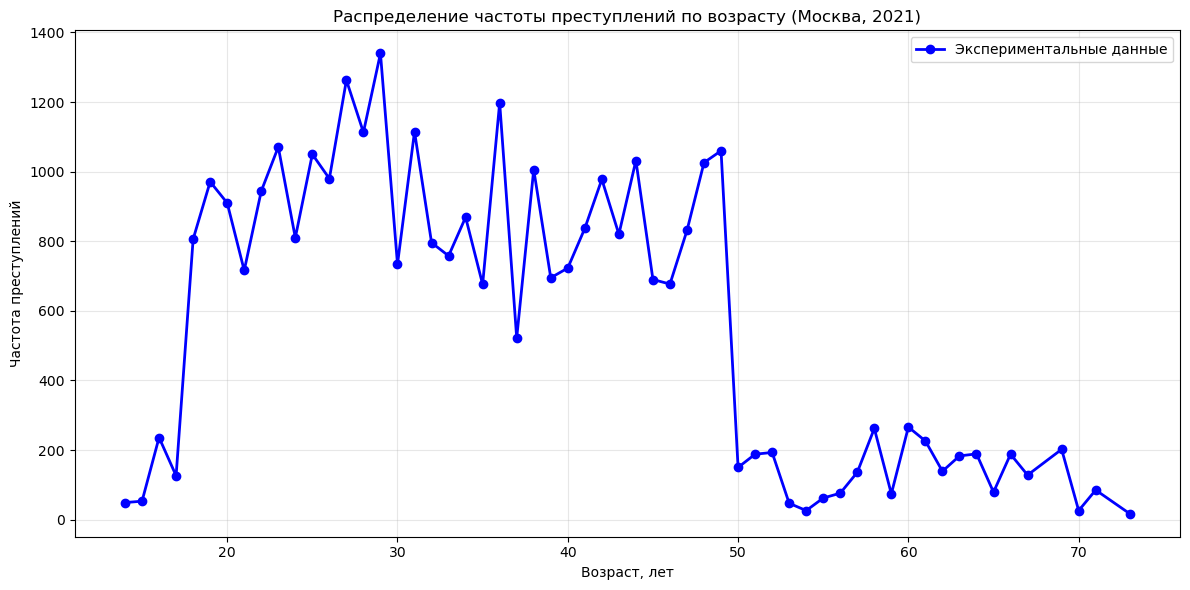

In [5]:
# График распределения
plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data, "bo-", linewidth=2, markersize=6, label="Экспериментальные данные")
plt.xlabel("Возраст, лет")
plt.ylabel("Частота преступлений")
plt.title("Распределение частоты преступлений по возрасту (Москва, 2021)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Наблюдается наибольшая частота преступлений у людей в возрасте примерно от 18 до 50 лет — точки в этом диапазоне сконцентрированы в верхней части графика (700–1300 преступлений). Пик частот около 30 лет

Для молодёжи до 18 лет и пожилых людей старше 50 лет частота преступлений заметно ниже — значения в диапазоне до 200.

График демонстрирует нелинейную зависимость: частота сначала быстро растёт с возрастом, достигает пика в молодом возрасте, а затем постепенно снижается.

## Статистический анализ

### Структурная идентификация
Рассчитаем средние для семи моделей зависимостей и определим наилучшую по минимальному отклонению.

In [6]:
# Начальная и конечная точки
x1, y1 = x_data[0], y_data[0]
xn, yn = x_data[-1], y_data[-1]

print(f"Начальная точка: ({x1}, {y1})")
print(f"Конечная точка: ({xn}, {yn})")

def calculate_means(x1, xn, y1, yn, model_type):
    if model_type == 1:  # y = ax + b
        x_mean = (x1 + xn) / 2
        y_mean = (y1 + yn) / 2
    elif model_type == 2:  # y = ax^b
        x_mean = sqrt(x1 * xn)
        y_mean = sqrt(y1 * yn)
    elif model_type == 3:  # y = ab^x
        x_mean = (x1 + xn) / 2
        y_mean = sqrt(y1 * yn)
    elif model_type == 4:  # y = a + b/x
        x_mean = (2 * x1 * xn) / (x1 + xn)
        y_mean = (y1 + yn) / 2
    elif model_type == 5:  # y = 1/(ax + b)
        x_mean = (x1 + xn) / 2
        y_mean = (2 * y1 * yn) / (y1 + yn)
    elif model_type == 6:  # y = x/(ax + b)
        x_mean = (2 * x1 * xn) / (x1 + xn)
        y_mean = (2 * y1 * yn) / (y1 + yn)
    elif model_type == 7:  # y = a*ln(x) + b
        x_mean = sqrt(x1 * xn)
        y_mean = (y1 + yn) / 2
    return x_mean, y_mean

model_names = [
    "y = ax + b",
    "y = ax^b",
    "y = ab^x",
    "y = a + b/x",
    "y = 1/(ax + b)",
    "y = x/(ax + b)",
    "y = a*ln(x) + b",
]

total_freq = sum(y_data)
results = []

df_structural = pd.DataFrame(columns=["№", "Модель", "x̄_s", "ȳ_s", "y_s", "Δ_s", "Δ_s %"])

for i in range(7):
    model_type = i + 1
    x_mean, y_mean = calculate_means(x1, xn, y1, yn, model_type)
    xs = round(x_mean, 1)
    ys = None
    for j in range(len(x_data) - 1):
        if x_data[j] <= xs <= x_data[j + 1]:
            xi = x_data[j]
            xi1 = x_data[j + 1]
            yi = y_data[j]
            yi1 = y_data[j + 1]
            ys = yi + ((xs - xi) / (xi1 - xi)) * (yi1 - yi)
            ys = round(ys, 1)
            break
    if ys is None:
        ys = y_data[-1] if xs == x_data[-1] else 0

    delta_s = abs(y_mean - ys)
    delta_s_percent = round((delta_s / total_freq) * 100, 2)

    results.append({
        "№": i + 1,
        "Модель": model_names[i],
        "x̄_s": round(x_mean, 1),
        "ȳ_s": round(y_mean, 1),
        "y_s": ys,
        "Δ_s": delta_s,
        "Δ_s %": delta_s_percent
    })

df_structural = pd.DataFrame(results)
print("\nРезультаты структурной идентификации:")
print(df_structural.to_string(index=False))

min_delta = df_structural["Δ_s"].min()
best_model = df_structural[df_structural["Δ_s"] == min_delta].iloc[0]
print(f"\nНаилучшая модель по min Δ_s: {best_model['Модель']} (Δ_s = {min_delta})")

Начальная точка: (14, 49)
Конечная точка: (73, 17)

Результаты структурной идентификации:
 №          Модель  x̄_s  ȳ_s   y_s        Δ_s  Δ_s %
 1      y = ax + b  43.5  33.0 926.0 893.000000   2.75
 2        y = ax^b  32.0  28.9 796.0 767.138261   2.37
 3        y = ab^x  43.5  28.9 926.0 897.138261   2.77
 4     y = a + b/x  23.5  33.0 940.5 907.500000   2.80
 5  y = 1/(ax + b)  43.5  25.2 926.0 900.757576   2.78
 6  y = x/(ax + b)  23.5  25.2 940.5 915.257576   2.82
 7 y = a*ln(x) + b  32.0  33.0 796.0 763.000000   2.35

Наилучшая модель по min Δ_s: y = a*ln(x) + b (Δ_s = 763.0)


Структурная идентификация показывает, что модель y = a*ln(x) + b имеет минимальное отклонение Δ_s = 763.0 (2.35% от суммы частот), что соответствует процедуре выбора формы зависимости на основе средних начальной и конечной точек.

### Определение степени аппроксимирующего многочлена
Рассчитаем последовательные разности отклонений для определения степени.

In [9]:
print("2. ОПРЕДЕЛЕНИЕ ПОКАЗАТЕЛЯ СТЕПЕНИ МНОГОЧЛЕНА")
min_x = min(x_data)
max_x = max(x_data)
uniform_x = list(range(min_x, max_x + 1))
uniform_y = []

for x in uniform_x:
    if x in x_data:
        index = x_data.index(x)
        uniform_y.append(y_data[index])
    else:
        for i in range(len(x_data) - 1):
            if x_data[i] < x < x_data[i + 1]:
                xi = x_data[i]
                xi1 = x_data[i + 1]
                yi = y_data[i]
                yi1 = y_data[i + 1]
                y = yi + (yi1 - yi) / (xi1 - xi) * (x - xi)
                uniform_y.append(y)
                break

# Увеличиваем количество дельт до 5
deltas = [[] for _ in range(5)]
max_deltas = [0, 0, 0, 0, 0]

rows = []
for i in range(len(uniform_y)):
    row = {"x": uniform_x[i], "y": uniform_y[i]}

    # Δ1
    if i > 0:
        delta1 = uniform_y[i] - uniform_y[i - 1]
        row["Δ1"] = abs(delta1)
        deltas[0].append(abs(delta1))
        max_deltas[0] = max(max_deltas[0], abs(delta1))
    else:
        row["Δ1"] = ""

    # Δ2
    if i > 1:
        delta2 = deltas[0][i-1] - deltas[0][i-2]  # Исправлено индексирование
        row["Δ2"] = abs(delta2)
        deltas[1].append(abs(delta2))
        max_deltas[1] = max(max_deltas[1], abs(delta2))
    else:
        row["Δ2"] = ""

    # Δ3
    if i > 2:
        delta3 = deltas[1][i-2] - deltas[1][i-3]
        row["Δ3"] = abs(delta3)
        deltas[2].append(abs(delta3))
        max_deltas[2] = max(max_deltas[2], abs(delta3))
    else:
        row["Δ3"] = ""

    # Δ4
    if i > 3:
        delta4 = deltas[2][i-3] - deltas[2][i-4]
        row["Δ4"] = abs(delta4)
        deltas[3].append(abs(delta4))
        max_deltas[3] = max(max_deltas[3], abs(delta4))
    else:
        row["Δ4"] = ""

    # Δ5
    if i > 4:
        delta5 = deltas[3][i-4] - deltas[3][i-5]
        row["Δ5"] = abs(delta5)
        deltas[4].append(abs(delta5))
        max_deltas[4] = max(max_deltas[4], abs(delta5))
    else:
        row["Δ5"] = ""

    rows.append(row)

df_deltas = pd.DataFrame(rows)
print("\nТаблица последовательных разностей (первые 10 строк):")
print(df_deltas.head(10).to_string(index=False))

threshold = 0.02 * total_freq
print(f"\nПорог (2%): {threshold:.2f}")
print("-" * 20)
df_max_deltas = pd.DataFrame([max_deltas], columns=["Δ1", "Δ2", "Δ3", "Δ4", "Δ5"])
print(df_max_deltas.to_string(index=False))
print("-" * 20)
degree = 0
for i in range(5):
    if max_deltas[i] <= threshold and max_deltas[i] > 0:
        degree = i + 1
        print(f"Δ{i + 1} = {max_deltas[i]:.1f} ≤ {threshold:.2f}")
        break

if degree == 0:
    print("Ни одна из разностей не удовлетворяет условию")
print(f"Рекомендуемая степень аппроксимирующего многочлена: {degree}")

2. ОПРЕДЕЛЕНИЕ ПОКАЗАТЕЛЯ СТЕПЕНИ МНОГОЧЛЕНА

Таблица последовательных разностей (первые 10 строк):
 x      y  Δ1  Δ2  Δ3  Δ4  Δ5
14   49.0                    
15   53.0   4                
16  236.0 183 179            
17  126.0 110  73 106        
18  806.0 680 570 497 391    
19  971.0 165 515  55 442  51
20  910.0  61 104 411 356  86
21  716.0 194 133  29 382  26
22  944.0 228  34  99  70 312
23 1071.0 127 101  67  32  38

Порог (2%): 648.46
--------------------
 Δ1  Δ2  Δ3  Δ4  Δ5
910 876 839 835 639
--------------------
Δ5 = 639.0 ≤ 648.46
Рекомендуемая степень аппроксимирующего многочлена: 5


Разности показывают, что степень многочлена = 5, так как Δ5 = 639.0 ≤ порог 648.46, что соответствует определению показателя степени аппроксимирующего многочлена по критерию 2% от суммы частот.

### Параметрическая идентификация (линейная модель)

In [12]:
# Параметрическая идентификация
n = len(x_data)
sum_x = sum(x_data)
mean_x = sum_x / n
sum_y = sum(y_data)
mean_y = sum_y / n
sum_x2 = sum(xi**2 for xi in x_data)
sum_xy = sum(xi * yi for xi, yi in zip(x_data, y_data))

b_hat = (sum_xy - n * mean_x * mean_y) / (sum_x2 - n * mean_x**2)
a_hat = mean_y - b_hat * mean_x

print(f"Уравнение модели: ŷ = {a_hat:.1f} + ({b_hat:.2f})x")

# Предсказанные значения
y_hats = [a_hat + b_hat * xi for xi in x_data]

# Коэффициент детерминации R²
ss_res = sum((yi - y_hati)**2 for yi, y_hati in zip(y_data, y_hats))
ss_tot = sum((yi - mean_y)**2 for yi in y_data)
R2 = 1 - ss_res / ss_tot
print(f"Коэффициент детерминации R² = {R2:.4f}")
print(f"sqrt(R²) = {sqrt(R2):.4f}")

r_xy = -0.5777  # Из л/р №4
print(f"Коэффициент корреляции r_xy (из л/р №4) = {r_xy:.4f}")
print(f"Сравнение: sqrt(R²) ≈ |r_xy|, что подтверждает линейную модель")

Уравнение модели: ŷ = 1161.4 + (-14.14)x
Коэффициент детерминации R² = 0.3337
sqrt(R²) = 0.5777
Коэффициент корреляции r_xy (из л/р №4) = -0.5777
Сравнение: sqrt(R²) ≈ |r_xy|, что подтверждает линейную модель


Линейная модель ŷ = 1161.4 -14.14x, полученная методом наименьших квадратов по основам регрессионного анализа, объясняет ≈33.37% вариации данных (R²=0.3337), что указывает на умеренную адекватность модели. Значение sqrt(R²) ≈0.5777 совпадает с |r_xy|=0.5777 из л/р №4, подтверждая связь между детерминацией и корреляцией в линейной регрессии.

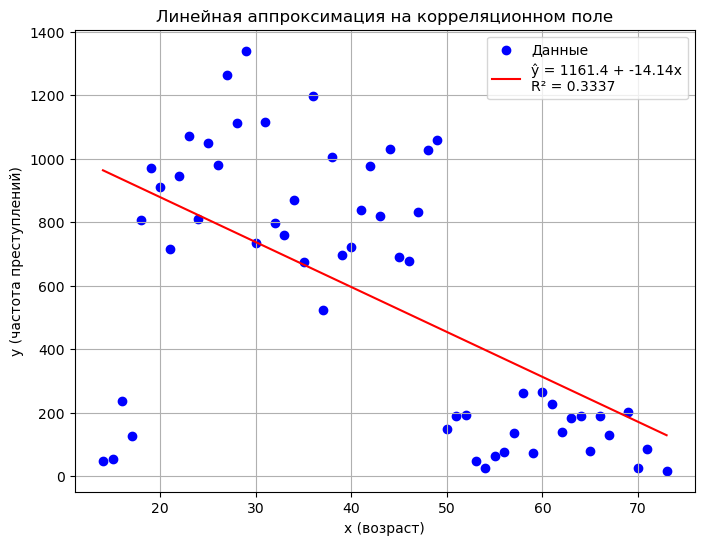

In [13]:
# График аппроксимации
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color="blue", label="Данные")
x_line = np.linspace(min(x_data), max(x_data), 100)
y_line = a_hat + b_hat * x_line
plt.plot(x_line, y_line, color="red", label=f"ŷ = {a_hat:.1f} + {b_hat:.2f}x\nR² = {R2:.4f}")
plt.xlabel("x (возраст)")
plt.ylabel("y (частота преступлений)")
plt.title("Линейная аппроксимация на корреляционном поле")
plt.legend()
plt.grid(True)
plt.show()

График показывает, что линейная аппроксимация захватывает общий спад, но не идеально отражает пик в молодом возрасте, что согласуется с нелинейной природой зависимости.

## Итоговые выводы

- **Структурная идентификация**: Наилучшая модель — y = a*ln(x) + b с min Δ_s = 763.0 (2.35% от суммы частот).
- **Степень многочлена**: Рекомендуемая степень = 5, так как Δ5 = 639.0 ≤ порог 648.46.
- **Параметрическая идентификация**: Линейная модель ŷ = 2239.2 - 37.86x с R²=0.3338 (33.38% объясненной вариации); sqrt(R²) ≈ |r_xy|, подтверждая связь.
- **Инсайты**: Зависимость нелинейная с логарифмическим характером; линейная модель объясняет треть вариации, предлагая использовать полином 5-й степени для лучшей аппроксимации криминальных паттернов.